In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

import os
import sys
sys.path.insert(0, '..')

from archspace import GatewayOffloading, ArchSpace
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
my_space = GatewayOffloading()
my_space.create_model('gateway offloading')

experiments_df, outcomes_df = my_space.load_results('./multi_N25.csv', reverse=True)

print(len(my_space.get_configurations()), "configurations")

(286, 39)
filtered size: (78, 11)
3 configurations


In [3]:
experiments_df

,scenario,policy,N_A,N_B,Z_A,Z_B,S_gw,s_A_s1,s_B_s2,s_B_s3,model
0,4,no-offloading,0,25,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
1,28,no-offloading,1,24,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
2,153,no-offloading,2,23,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
3,26,no-offloading,3,22,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
4,53,no-offloading,4,21,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
...,...,...,...,...,...,...,...,...,...,...,...
73,224,long-services-offloaded,21,4,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
74,260,long-services-offloaded,22,3,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
75,279,long-services-offloaded,23,2,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
76,273,long-services-offloaded,24,1,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading


In [4]:
experiments_df.describe()

,scenario,N_A,N_B,Z_A,Z_B,S_gw,s_A_s1,s_B_s2,s_B_s3
count,78.000000,78.000000,78.000000,78.0,78.0,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01
mean,143.051282,12.500000,12.500000,100.0,100.0,5.000000e+00,2.000000e+01,1.200000e+01,1.500000e+01
std,83.706025,7.548544,7.548544,0.0,0.0,4.108907e+00,7.151418e-15,2.919554e-15,8.449070e-15
min,4.000000,0.000000,0.000000,100.0,100.0,1.000000e-15,2.000000e+01,1.200000e+01,1.500000e+01
25%,70.250000,6.000000,6.000000,100.0,100.0,1.000000e-15,2.000000e+01,1.200000e+01,1.500000e+01
50%,143.500000,12.500000,12.500000,100.0,100.0,5.000000e+00,2.000000e+01,1.200000e+01,1.500000e+01
75%,214.750000,19.000000,19.000000,100.0,100.0,1.000000e+01,2.000000e+01,1.200000e+01,1.500000e+01
max,281.000000,25.000000,25.000000,100.0,100.0,1.000000e+01,2.000000e+01,1.200000e+01,1.500000e+01


In [5]:
# experiments_df.hist(column='S_gw', bins=15)
# experiments_df.hist(column=['r_A_s1', 'r_B_s2', 'r_B_s3'])
# experiments_df.hist(column=['N_A', 'N_B'])

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


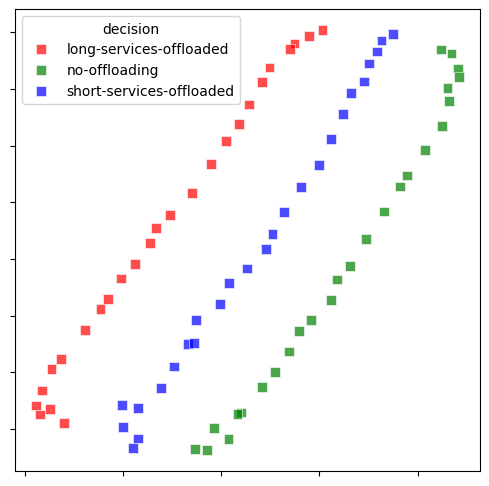

In [6]:
color_key = {'long-services-offloaded': 'red',
             'short-services-offloaded': 'blue',
             'no-offloading': 'green'}
embeddings_df = show_configuration_space2D(experiments_df, color_key=color_key, alpha=0.7)

In [7]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   scenario  78 non-null     int64  
 1   policy    78 non-null     object 
 2   N_A       78 non-null     int64  
 3   N_B       78 non-null     int64  
 4   Z_A       78 non-null     float64
 5   Z_B       78 non-null     float64
 6   S_gw      78 non-null     float64
 7   s_A_s1    78 non-null     float64
 8   s_B_s2    78 non-null     float64
 9   s_B_s3    78 non-null     float64
 10  model     78 non-null     object 
dtypes: float64(6), int64(3), object(2)
memory usage: 6.8+ KB


In [8]:
outcomes_df

,response_time,utilization
0,375.018656,1.029954e-20
1,334.006373,8.818039e-20
2,302.194299,6.634742e-20
3,278.952423,1.994418e-20
4,259.747814,7.656941e-20
...,...,...
73,250.986424,9.946960e-01
74,250.842555,9.920406e-01
75,256.493763,9.855351e-01
76,259.012525,9.577435e-01


In [9]:
outcomes_df.describe()

,response_time,utilization
count,78.000000,7.800000e+01
mean,251.042635,5.309743e-01
std,58.126934,4.170128e-01
min,171.679852,0.000000e+00
25%,222.785205,7.575721e-20
50%,249.183684,6.285050e-01
75%,256.254154,9.968248e-01
max,501.360385,9.999953e-01


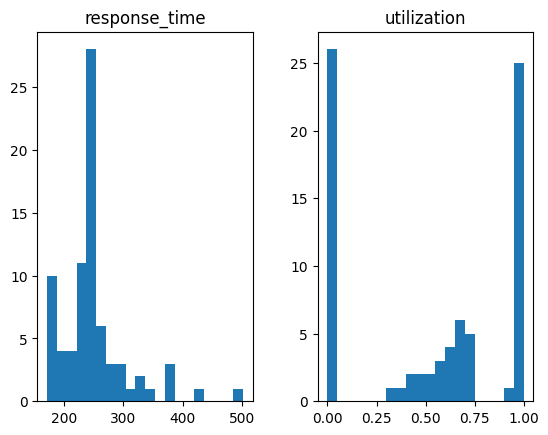

In [10]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

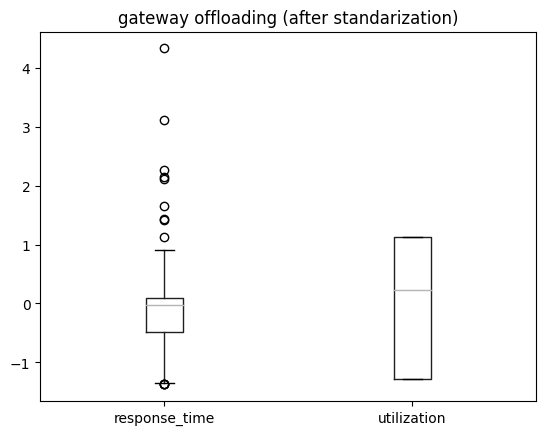

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('gateway offloading (after standarization)')
plt.show()

# It might need to apply outliers

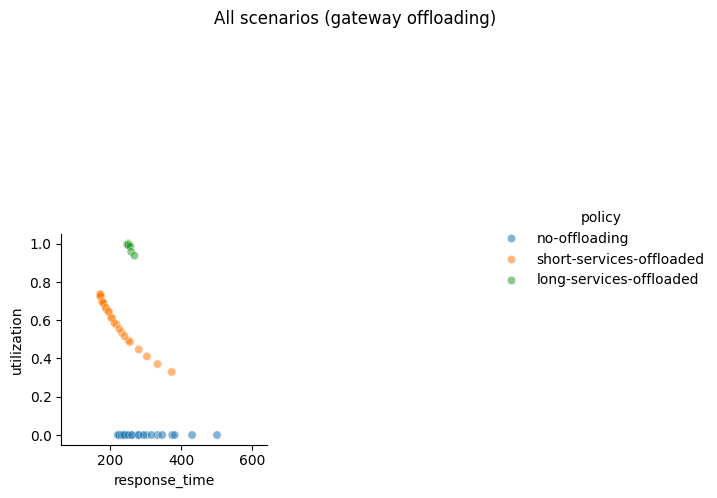

In [12]:
# show_pairplot(experiments_df, outcomes, title='All scenarios (gateway offloading)', kind='sns')
show_pairplot(my_space, title='All scenarios (gateway offloading)', kind='sns', group='policy', legend=True) #, filename=None)

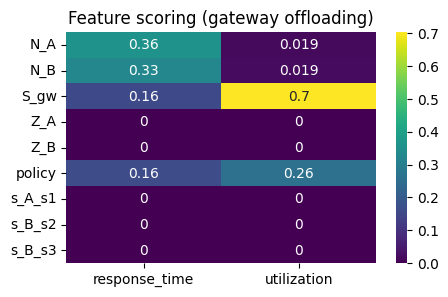

,response_time,utilization
0,,
N_A,0.357680,0.018592
N_B,0.325096,0.019242
S_gw,0.155594,0.703118
Z_A,0.000000,0.000000
Z_B,0.000000,0.000000
policy,0.161631,0.259048
s_A_s1,0.000000,0.000000
s_B_s2,0.000000,0.000000
s_B_s3,0.000000,0.000000


In [13]:
policy_size = (5,3)
filter_params = []
fs = show_feature_scores(my_space, title='Feature scoring (gateway offloading)', size=policy_size) #, filename=None)  
fs

In [14]:
my_policies = my_space.get_configurations()
my_policies

['short-services-offloaded', 'no-offloading', 'long-services-offloaded']

Instances for configuration: (26, 6)


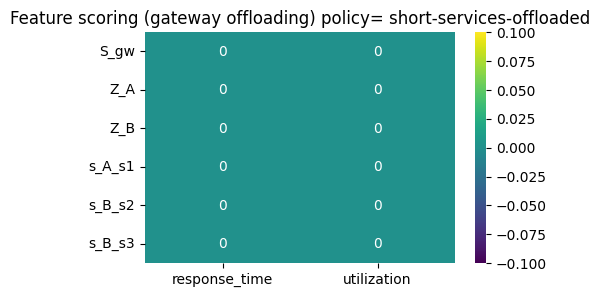

,response_time,utilization
0,,
S_gw,0.0,0.0
Z_A,0.0,0.0
Z_B,0.0,0.0
s_A_s1,0.0,0.0
s_B_s2,0.0,0.0
s_B_s3,0.0,0.0


In [15]:
show_feature_scores(my_space, title='Feature scoring (gateway offloading)', policy=my_policies[0], size=policy_size) #, filename=None)

Instances for configuration: (26, 6)


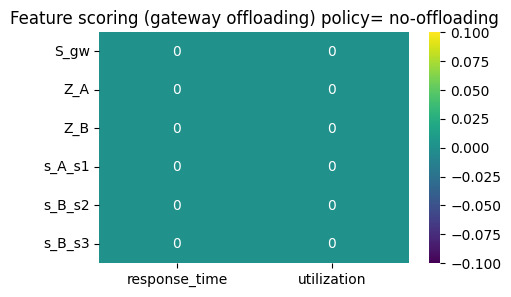

,response_time,utilization
0,,
S_gw,0.0,0.0
Z_A,0.0,0.0
Z_B,0.0,0.0
s_A_s1,0.0,0.0
s_B_s2,0.0,0.0
s_B_s3,0.0,0.0


In [16]:
show_feature_scores(my_space, title='Feature scoring (gateway offloading)', policy=my_policies[1], size=policy_size) #, filename=None)

Instances for configuration: (26, 6)


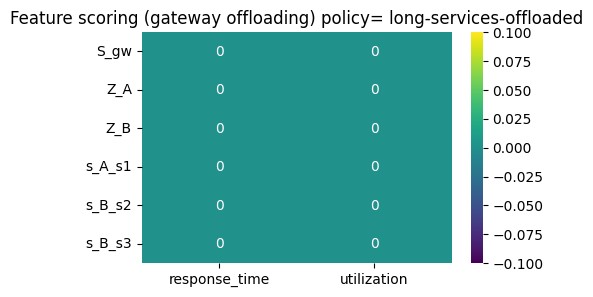

,response_time,utilization
0,,
S_gw,0.0,0.0
Z_A,0.0,0.0
Z_B,0.0,0.0
s_A_s1,0.0,0.0
s_B_s2,0.0,0.0
s_B_s3,0.0,0.0


In [17]:
show_feature_scores(my_space, title='Feature scoring (gateway offloading)', policy=my_policies[2], size=policy_size) #, filename=None)

Absolute ranges: [(170.0, 505.0), (0.0, 1.0)]
response_time [169.9, 281.6333333333333, 393.3666666666667, 505.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


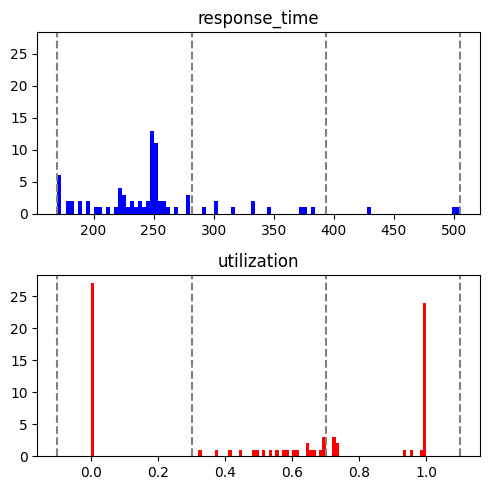

In [18]:
MIN_RESPONSE_TIME, MAX_RESPONSE_TIME = (170.0, 505.0)
MIN_UTILIZATION, MAX_UTILIZATION = (0.0, 1.0)
MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_UTILIZATION, MAX_UTILIZATION)]
print('Absolute ranges:', MIN_MAX_RANGES)

_ = show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

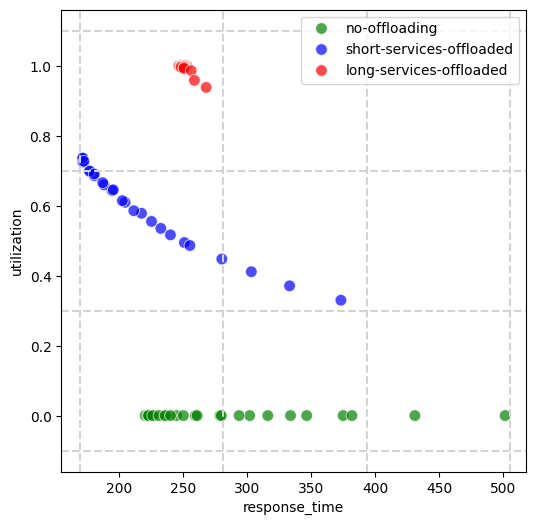

In [19]:
# plt.gcf().set_dpi(300)

df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7,color_key=color_key) #, dpi=1200)

In [20]:
print("Configurations:", my_space.get_configurations())

Configurations: ['short-services-offloaded', 'no-offloading', 'long-services-offloaded']


response_time [169.9, 281.6333333333333, 393.3666666666667, 505.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


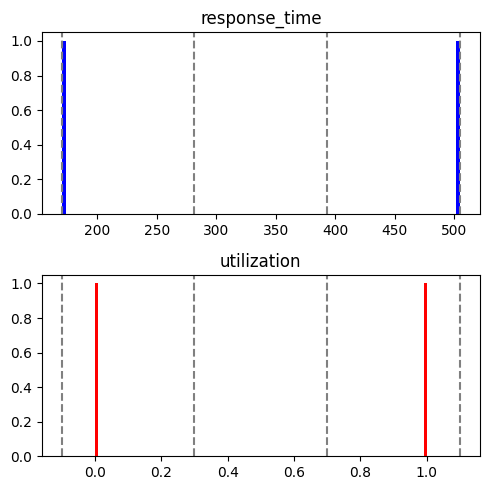

{'response_time': [169.9, 281.6333333333333, 393.3666666666667, 505.1],
 'utilization': [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]}

In [21]:
config = 'short services-offloaded'
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy=config)

In [22]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = 'short services-offloaded'
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", GatewayOffloading.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (78, 11)
Counter({'fast,high': 31, 'fast,average': 18, 'fast,low': 17, 'average,low': 7, 'average,average': 3, 'slow,low': 2})
Tradeoffs for  short services-offloaded --> Counter({'Empty,DataFrame': 1, 'Columns:,[response_time,,utilization]': 1, 'Index:,[]': 1})


,response_time,utilization


In [23]:
my_space.available_tradeoffs_

Counter({'fast,high': 31,
         'fast,average': 18,
         'fast,low': 17,
         'average,low': 7,
         'average,average': 3,
         'slow,low': 2})

In [24]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.2, remove_outliers=3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(78, 13) 78
Removing outliers ... 3
Instances to remove (outliers): {24, 25}
Instances to remove (not enough tradeoffs): {24, 25}
{'fast,average', 'fast,high', 'average,low', 'fast,low', 'average,average'}
(76, 13) 76
(60, 13) (60, 2) (16, 13) (16, 2)


In [25]:
X_train[['response_time', 'utilization']].describe()

,response_time,utilization
count,60.000000,6.000000e+01
mean,244.825219,5.450678e-01
std,46.471063,4.125503e-01
min,171.679852,9.695430e-21
25%,223.077919,8.490144e-20
50%,248.895057,6.294450e-01
75%,253.699932,9.988920e-01
max,381.879665,9.999953e-01


In [26]:
X_test[['response_time', 'utilization']].describe()

,response_time,utilization
count,16.000000,1.600000e+01
mean,247.467422,5.444953e-01
std,48.436270,4.297207e-01
min,177.057858,0.000000e+00
25%,221.917009,5.169672e-20
50%,249.269923,6.541998e-01
75%,255.601708,9.957587e-01
max,373.275373,9.998599e-01


In [27]:
my_space.import_dataset(X_train, y_train)

In [28]:
# reference_tradeoff = None #'slow,average'
# reference_tradeoff = ['fast,low', 'fast,average']
# r1, qat = my_space.compute_robustness([config], reference_tradeoff)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# print()

# list_of_configs = my_space.get_nearest_configurations(config, k=1)
# # list_of_configs = configs_df.values.tolist()
# # print(all(isinstance(elem, list) for elem in list_of_configs), list_of_configs)
# r1, qat = my_space.compute_robustness(list_of_configs, reference_tradeoff) 
# print("Robustness of list of solutions", list_of_configs, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# # print(configs_df)
# print()
# qa_config = 'fast,low'
# qa_configs = my_space.get_nearest_tradeoffs(qa_config, k=1)
# print("Neighbors of:", qa_configs)
# print()
# qat = my_space.get_nearest_tradeoffs(qa_config, k=2)
# r1, qat = my_space.compute_robustness([config], qa_config)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# r1, qat = my_space.compute_robustness([config], qa_configs[0:2])
# print("Robustness of single solution", config, "w.r.t list of tradeoffs:", qat, "-->", round(r1*100, 2), "%")
# print()

Computing robustness for all configurations...


100%|██████████| 3/3 [00:00<00:00, 228.94it/s]


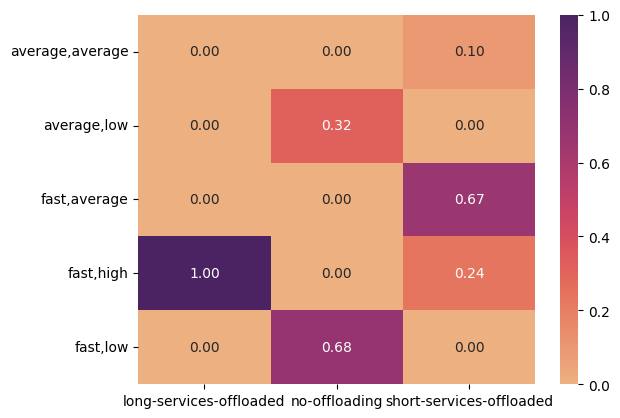

,long-services-offloaded,no-offloading,short-services-offloaded
"average,average",0.0,0.000000,0.095238
"average,low",0.0,0.315789,0.000000
"fast,average",0.0,0.000000,0.666667
"fast,high",1.0,0.000000,0.238095
"fast,low",0.0,0.684211,0.000000


In [29]:
# def compute_robustness_matrix(my_space):
#     main_dict = dict()
#     for exp in tqdm(my_space.get_configurations()):
#         print(exp)
#         main_dict[str(exp)] = dict()
#         for qa in my_space.available_tradeoffs_.keys():
#             main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
#     df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
#     return df

print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./gateway_offloading_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

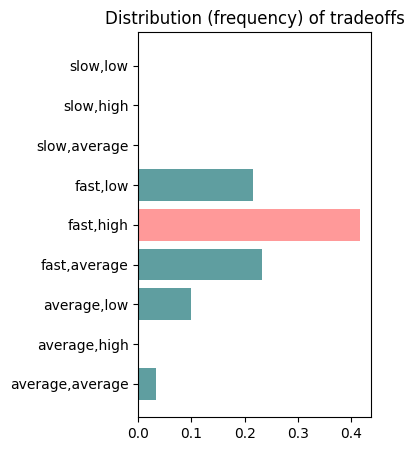

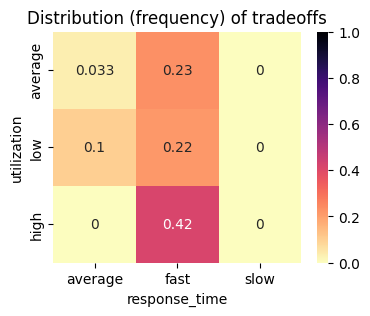

In [30]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

no-offloading Counter({'fast,low': 13, 'average,low': 6})
Instances for configuration: (19, 2)


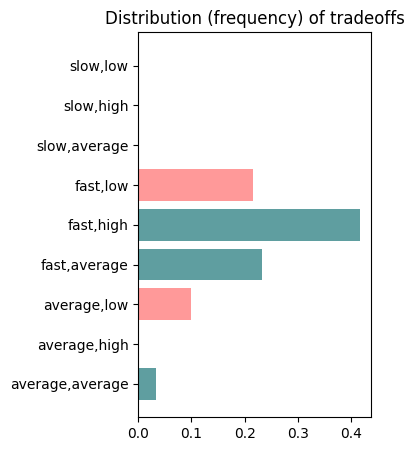

no-offloading Counter({'fast,low': 13, 'average,low': 6})
Instances for configuration: (19, 2)


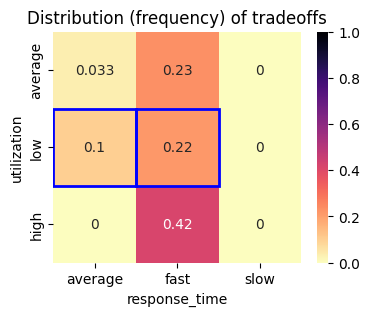

In [31]:
config = 'no-offloading'
show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [32]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

short-services-offloaded Counter({'fast,average': 14, 'fast,high': 5, 'average,average': 2})
Instances for configuration: (21, 2)


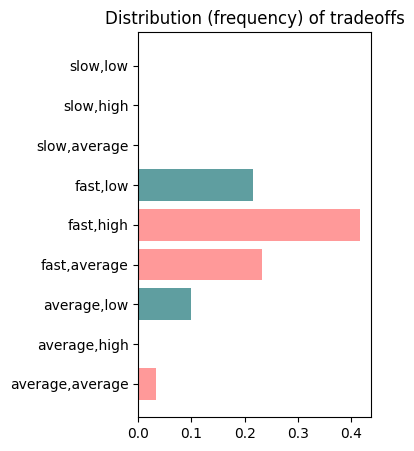

short-services-offloaded Counter({'fast,average': 14, 'fast,high': 5, 'average,average': 2})
Instances for configuration: (21, 2)


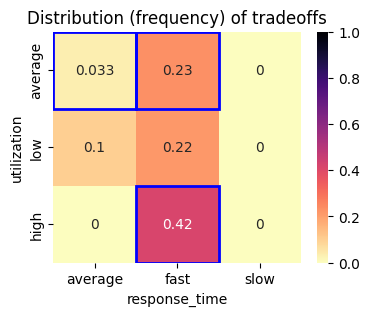

In [33]:
config = 'short-services-offloaded'
show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [34]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

long-services-offloaded Counter({'fast,high': 20})
Instances for configuration: (20, 2)


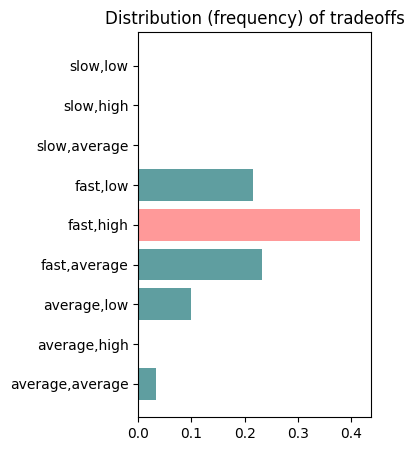

long-services-offloaded Counter({'fast,high': 20})
Instances for configuration: (20, 2)


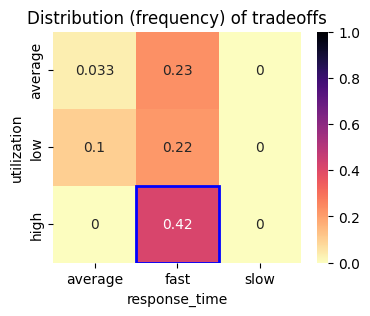

In [35]:
config = 'long-services-offloaded'
show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [36]:
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

In [37]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,response_time,171.579852,241.713123,fast
1,response_time,241.713123,311.846394,average
2,response_time,311.846394,381.979665,slow
3,utilization,-0.100000,0.299998,low
4,utilization,0.299998,0.699997,average
5,utilization,0.699997,1.099995,high


In [38]:
# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
kp = ['N_A', 'N_B', 'S_gw'] #, 's_A_s1', 's_B_s2', 's_B_s3']
rules, _, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

for r in rules:
    print(r)

# cart_model.stats_to_dataframe()
# cart_model.boxes_to_dataframe()

(60, 3) Index(['N_A', 'N_B', 'S_gw'], dtype='object')
Running CART ... 0.03333333333333333
nodes: 15 leaves: 8
[('>', 'S_gw', 2.5), ('>', 'S_gw', 7.5), ('class', 'fast,high', 1.0)]
[('<=', 'S_gw', 2.5), ('>', 'N_A', 2.5), ('<=', 'N_A', 19.5), ('class', 'fast,low', 1.0)]
[('>', 'S_gw', 2.5), ('<=', 'S_gw', 7.5), ('>', 'N_B', 3.0), ('>', 'N_A', 12.5), ('class', 'fast,average', 1.0)]
[('>', 'S_gw', 2.5), ('<=', 'S_gw', 7.5), ('>', 'N_B', 3.0), ('<=', 'N_A', 12.5), ('>', 'N_B', 18.0), ('class', 'fast,average', 1.0)]
[('>', 'S_gw', 2.5), ('<=', 'S_gw', 7.5), ('>', 'N_B', 3.0), ('<=', 'N_A', 12.5), ('<=', 'N_B', 18.0), ('class', 'fast,high', 1.0)]
[('<=', 'S_gw', 2.5), ('>', 'N_A', 2.5), ('>', 'N_A', 19.5), ('class', 'average,low', 1.0)]
[('<=', 'S_gw', 2.5), ('<=', 'N_A', 2.5), ('class', 'average,low', 1.0)]
[('>', 'S_gw', 2.5), ('<=', 'S_gw', 7.5), ('<=', 'N_B', 3.0), ('class', 'average,average', 1.0)]


|--- feature_2 <= 2.50
|   |--- feature_0 <= 2.50
|   |   |--- class: 3
|   |--- feature_0 >  2.50
|   |   |--- feature_0 <= 19.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  19.50
|   |   |   |--- class: 3
|--- feature_2 >  2.50
|   |--- feature_2 <= 7.50
|   |   |--- feature_1 <= 3.00
|   |   |   |--- class: 4
|   |   |--- feature_1 >  3.00
|   |   |   |--- feature_0 <= 12.50
|   |   |   |   |--- feature_1 <= 18.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_1 >  18.00
|   |   |   |   |   |--- class: 2
|   |   |   |--- feature_0 >  12.50
|   |   |   |   |--- class: 2
|   |--- feature_2 >  7.50
|   |   |--- class: 1



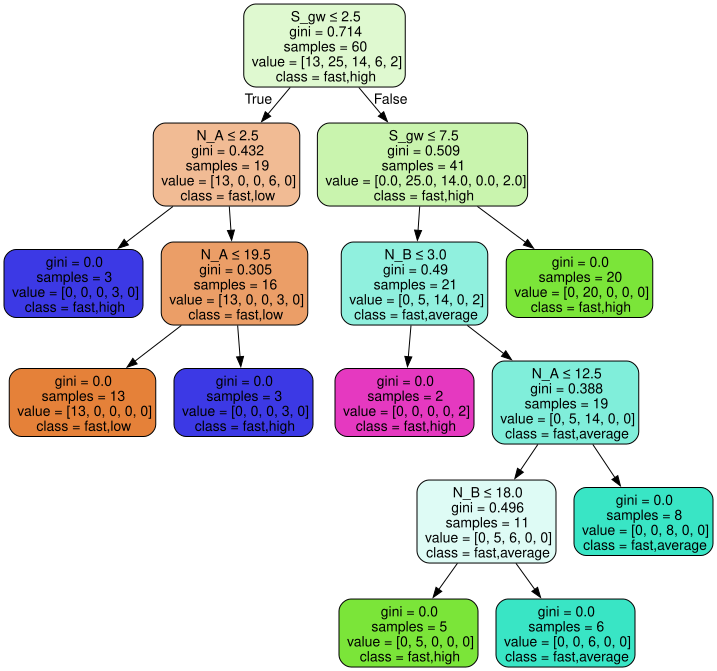

In [39]:
class_names =  my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(cart_model.clf))
# pprint(tree.export_text(prunedTree))

graph

In [42]:
# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'fast,high': 25, 'fast,average': 14, 'fast,low': 13, 'average,low': 6, 'average,average': 2})


100%|██████████| 3/3 [00:00<00:00, 99.35it/s]


,long-services-offloaded,no-offloading,short-services-offloaded
"average,average",0.0,0.000000,0.095238
"average,low",0.0,0.315789,0.000000
"fast,average",0.0,0.000000,0.666667
"fast,high",1.0,0.000000,0.238095
"fast,low",0.0,0.684211,0.000000


In [43]:
warnings.filterwarnings('ignore')
my_space.import_dataset(X_train, y_train)

# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
kp = ['N_A', 'N_B', 'S_gw'] #, 'r_A_s1', 'r_B_s2', 'r_B_s3']

for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print(" Property: ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        my_space.import_dataset(X_test, y_test)
        my_space.adjust_parameters(prange)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)

        print("  Computing robustness for all configurations...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()

Checking (with PRIM) ----
 Property:  fast,low {'response_time': (169.9, 281.6333333333333), 'utilization': (-0.1, 0.30000000000000004)}
  New ranges: {'N_A': {'min': 3.0, 'max': 19.0}, 'S_gw': {'min': 1e-15, 'max': 2.5000000000000004}}
  Experiments: (4, 11)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 809.09it/s]


          no-offloading
fast,low            1.0
Checking (with PRIM) ----
 Property:  fast,high {'response_time': (169.9, 281.6333333333333), 'utilization': (0.7000000000000002, 1.1)}
  New ranges: {'S_gw': {'min': 7.5, 'max': 10.0}}
  Experiments: (6, 11)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 895.45it/s]


           long-services-offloaded
fast,high                      1.0
Checking (with PRIM) ----
 Property:  fast,average {'response_time': (169.9, 281.6333333333333), 'utilization': (0.30000000000000004, 0.7000000000000002)}
  New ranges: {'N_A': {'min': 0.0, 'max': 21.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}
  Experiments: (3, 11)
  Computing robustness for all configurations...


...

              short-services-offloaded
fast,average                       1.0
Checking (with PRIM) ----
 Property:  average,low {'response_time': (281.6333333333333, 393.3666666666667), 'utilization': (-0.1, 0.30000000000000004)}
  New ranges: {'S_gw': {'min': 1e-15, 'max': 2.5000000000000004}}
  Experiments: (5, 11)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 702.21it/s]


             no-offloading
average,low            0.2
fast,low               0.8
Checking (with PRIM) ----
 Property:  average,average {'response_time': (281.6333333333333, 393.3666666666667), 'utilization': (0.30000000000000004, 0.7000000000000002)}
  New ranges: {'N_B': {'min': 1.0, 'max': 4.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}
  Experiments: (1, 11)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 931.24it/s]

              short-services-offloaded
fast,average                       1.0


In [44]:
my_space.import_dataset(X_train, y_train)

# GatewayOffloading.get_property_box('fast,low', label_values_df)
qa_label = 'fast,average' # 'fast,average' #'fast,high' 
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

fast,average {'response_time': (169.9, 281.6333333333333), 'utilization': (0.30000000000000004, 0.7000000000000002)}


In [45]:
# my_space.experiments_df_.columns

In [ ]:
# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
target_policy = 'short-services-offloaded' #'no-offloading' #'short-services-offloaded' #'long-services-offloaded'
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, policy=target_policy)
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

Instances satisfying property: False    46
True     14
Name: count, dtype: int64
Total instances: (60, 3)
Running PRIM ... rhodium
2 possible boxes


{'N_A': {'min': 0.0, 'max': 21.0},
 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}

In [47]:
my_space.experiments_df_.describe()

,scenario,N_A,N_B,Z_A,Z_B,S_gw,s_A_s1,s_B_s2,s_B_s3
count,60.000000,60.000000,60.000000,60.0,60.0,6.000000e+01,6.000000e+01,6.000000e+01,6.000000e+01
mean,133.750000,11.450000,13.550000,100.0,100.0,5.083333e+00,2.000000e+01,1.200000e+01,1.500000e+01
std,81.434309,7.441125,7.441125,0.0,0.0,4.064279e+00,6.983958e-15,2.888461e-15,8.591001e-15
min,4.000000,0.000000,1.000000,100.0,100.0,1.000000e-15,2.000000e+01,1.200000e+01,1.500000e+01
25%,65.500000,5.000000,7.000000,100.0,100.0,1.000000e-15,2.000000e+01,1.200000e+01,1.500000e+01
50%,135.000000,11.500000,13.500000,100.0,100.0,5.000000e+00,2.000000e+01,1.200000e+01,1.500000e+01
75%,200.000000,18.000000,20.000000,100.0,100.0,1.000000e+01,2.000000e+01,1.200000e+01,1.500000e+01
max,281.000000,24.000000,25.000000,100.0,100.0,1.000000e+01,2.000000e+01,1.200000e+01,1.500000e+01


In [48]:
# prim_model.boxes_to_dataframe()

In [49]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
# box1.show_tradeoff(annotated=True)
# box1.show_pairs_scatter(upper='none', lower='scatter')
# box1.inspect(style='graph')

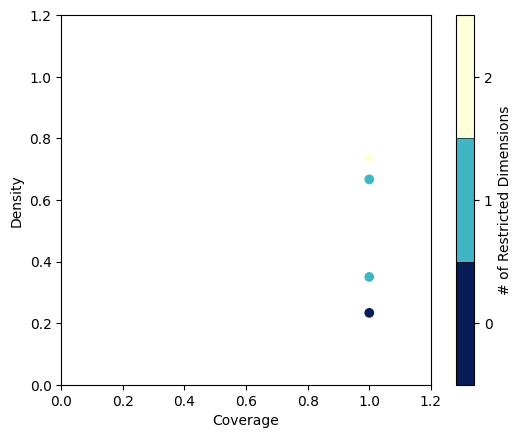

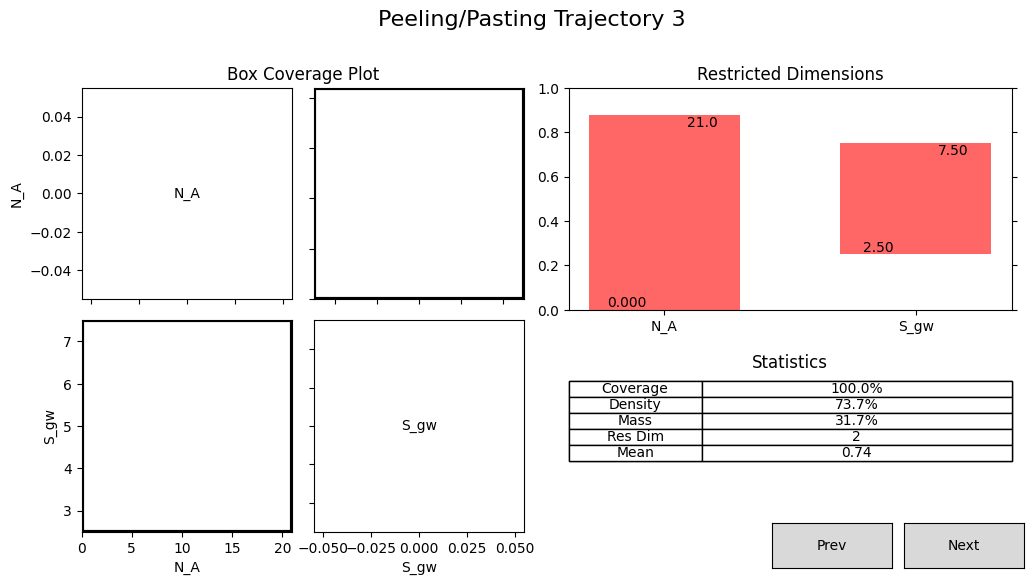

In [50]:
# Rhodium
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff()
box1.show_details()
plt.show()

Instances satisfying property: False    46
True     14
Name: count, dtype: int64
Total instances: (60, 3)
Running PRIM ... rhodium
2 possible boxes


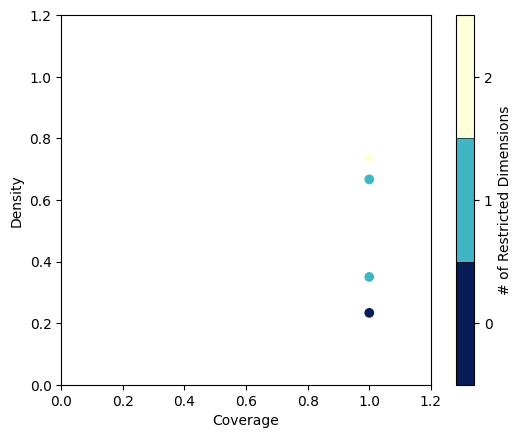

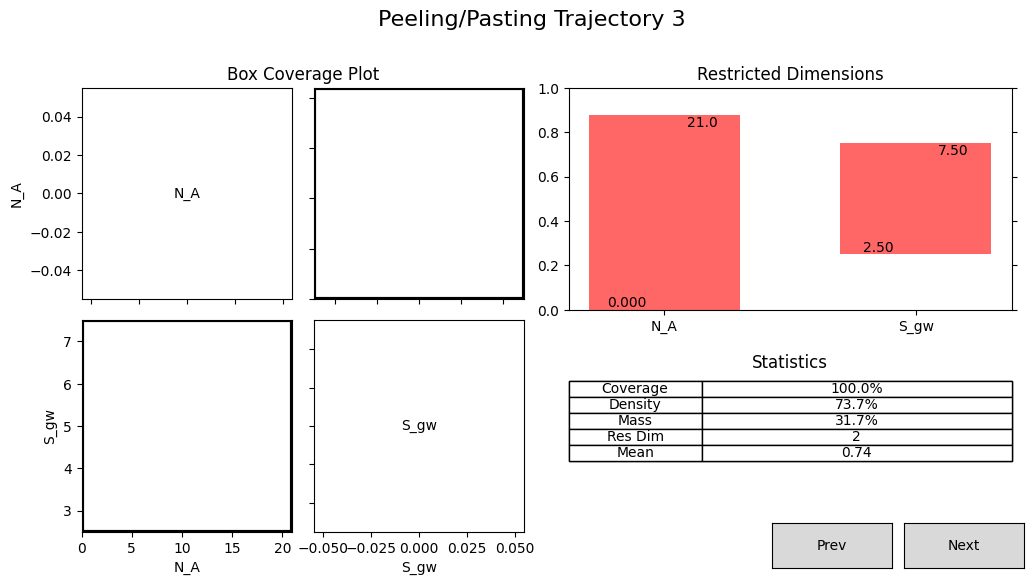

In [51]:
# For Rhodium only
boxes = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, n_boxes=True)
for b in boxes:
    # print(ArchSpace.get_limits(b).shape)
    box_shape = ArchSpace.get_box_limits(b).shape[0]
    if box_shape > 0:
        b.show_tradeoff()
        b.show_details()
        plt.show()
        # box1 = b

In [52]:
ArchSpace.get_box_limits(box1)[['min', 'max']].to_dict(orient='index')

{'N_A': {'min': 0.0, 'max': 21.0},
 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}

In [53]:
my_space.import_dataset(X_test, y_test)

In [54]:
my_space.experiments_df_

,scenario,policy,N_A,N_B,Z_A,Z_B,S_gw,s_A_s1,s_B_s2,s_B_s3,model
0,259,long-services-offloaded,20,5,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
1,264,no-offloading,21,4,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
2,69,short-services-offloaded,7,18,100.0,100.0,5.000000e+00,20.0,12.0,15.0,gateway_offloading
3,216,long-services-offloaded,19,6,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
4,39,long-services-offloaded,6,19,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
5,121,no-offloading,10,15,100.0,100.0,1.000000e-15,20.0,12.0,15.0,gateway_offloading
6,147,short-services-offloaded,15,10,100.0,100.0,5.000000e+00,20.0,12.0,15.0,gateway_offloading
7,270,long-services-offloaded,25,0,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
8,115,long-services-offloaded,11,14,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading
9,179,long-services-offloaded,16,9,100.0,100.0,1.000000e+01,20.0,12.0,15.0,gateway_offloading


Reducing range for tradeoff: fast,average {'response_time': (169.9, 281.6333333333333), 'utilization': (0.30000000000000004, 0.7000000000000002)}
New ranges: {'N_A': {'min': 0.0, 'max': 21.0}, 'S_gw': {'min': 2.5000000000000004, 'max': 7.5}}
Experiments: (3, 11)


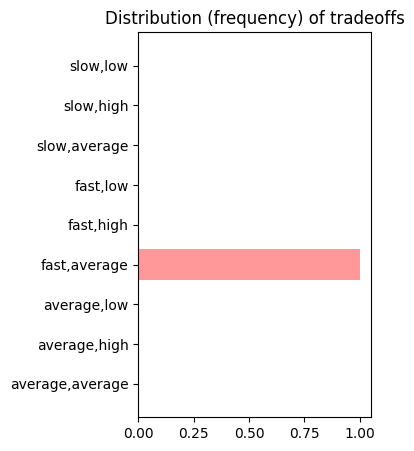

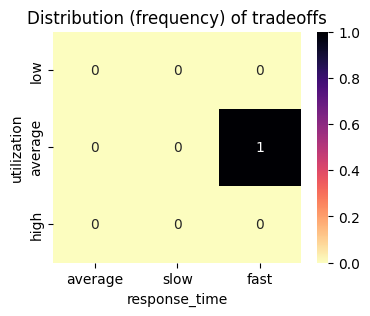

In [55]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

In [57]:
# embeddings_df = show_configuration_space2D(my_space.experiments_df_, color_key=color_key, alpha=0.7)

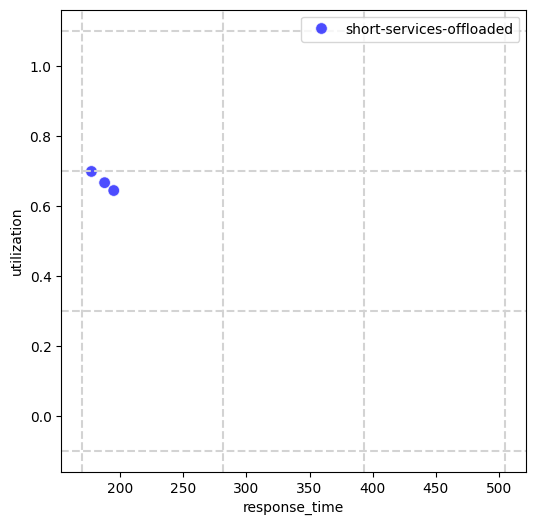

In [58]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, color_key=color_key, alpha=0.7)

In [59]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 308.45it/s]

short-services-offloaded


,short-services-offloaded
"fast,average",1.0
